In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [31]:
end_date = datetime.strptime('2020-01-01', '%Y-%m-%d')
start_date = end_date - timedelta(days=365*5)

In [32]:
tickers = ['GOOGL', 'TSLA', 'AMZN', 'JPM', 'XOM', 'ASML', 'RACE', 'SIE.DE', 'GLD', 'BTC-USD']

returns_df = pd.DataFrame()
for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date, interval='1mo')
    returns_df[ticker] = data['Close'].pct_change()

returns_df = returns_df.dropna() 
print(returns_df.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

               GOOGL      TSLA      AMZN       JPM       XOM      ASML  \
Date                                                                     
2015-11-01  0.034527  0.112743  0.062151  0.045309 -0.013053 -0.000754   
2015-12-01  0.019873  0.042343  0.016682 -0.009748 -0.037111 -0.042602   
2016-01-01 -0.021414 -0.203367 -0.131515 -0.098894 -0.001283  0.034584   
2016-02-01 -0.057963  0.003818 -0.058739 -0.047434  0.029544 -0.008929   
2016-03-01  0.063690  0.197155  0.074423  0.051865  0.052385  0.102944   

                RACE    SIE.DE       GLD   BTC-USD  
Date                                                
2015-11-01 -0.080904  0.072568 -0.067521  0.201024  
2015-12-01  0.035599 -0.084165 -0.004513  0.141116  
2016-01-01 -0.171458 -0.018914  0.054110 -0.143532  
2016-02-01 -0.045009  0.012546  0.109303  0.186920  
2016-03-01  0.097946  0.089984 -0.008429 -0.047905  


In [33]:
data_rf = yf.download('^TYX', start=start_date, end=end_date, interval='1mo')
rf_annual_pct = data_rf["Close"].mean()
rf = float(rf_annual_pct / 100)
rf = (1 + rf)**(1/12) - 1 

spy_data = yf.download('SPY', start=start_date, end=end_date, interval='1mo')
spy_returns = spy_data["Close"].pct_change()
spy_returns = spy_returns.dropna()
spy_mean = float(spy_returns.mean())
spy_var = float(spy_returns.var())

[*********************100%***********************]  1 of 1 completed
C:\Users\Riccardo\AppData\Local\Temp\ipykernel_22856\1489000135.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  rf = float(rf_annual_pct / 100)
[*********************100%***********************]  1 of 1 completed
C:\Users\Riccardo\AppData\Local\Temp\ipykernel_22856\1489000135.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  spy_mean = float(spy_returns.mean())
C:\Users\Riccardo\AppData\Local\Temp\ipykernel_22856\1489000135.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  spy_var = float(spy_returns.var())


In [34]:
statistics_df = pd.DataFrame({
    'Expected Return': returns_df.mean(),          
    'Variance': returns_df.var(),                  
    'Standard Deviation': returns_df.std()         
})

# Rinomina l'indice
statistics_df.index.name = 'Ticker'
statistics_df = statistics_df.round(6)
print("\nPortfolio Statistics:")
print(statistics_df)


Portfolio Statistics:
         Expected Return  Variance  Standard Deviation
Ticker                                                
GOOGL           0.013389  0.002855            0.053431
TSLA            0.021816  0.015931            0.126219
AMZN            0.024751  0.005866            0.076592
JPM             0.019564  0.003464            0.058853
XOM             0.001368  0.002812            0.053028
ASML            0.026413  0.004186            0.064697
RACE            0.028205  0.007117            0.084360
SIE.DE          0.009658  0.003509            0.059234
GLD             0.006123  0.001546            0.039320
BTC-USD         0.090166  0.058996            0.242890


In [35]:
combined_df = returns_df.copy()

combined_df['SPY'] = spy_returns
combined_df = combined_df.dropna()

# Calcola la matrice di covarianza completa
full_cov_matrix = combined_df.cov()

# Estrae solo le covarianze con URTH (escludi l'auto-covarianza)
cov_with_spy = full_cov_matrix.loc[tickers, 'SPY']

print("\nCovarianze con SPY:")
print(cov_with_spy.round(6))


Covarianze con SPY:
Ticker
GOOGL      0.001134
TSLA       0.000972
AMZN       0.001755
JPM        0.001340
XOM        0.001057
ASML       0.001443
RACE       0.001449
SIE.DE     0.000967
GLD       -0.000153
BTC-USD    0.000001
Name: SPY, dtype: float64


In [36]:
# Aggiunge le covarianze al DataFrame delle statistiche
available_tickers = [ticker for ticker in tickers if ticker in cov_with_spy.index]
statistics_df_filtered = statistics_df.loc[available_tickers]

statistics_df_filtered['Covariance_with_SPY'] = cov_with_spy.loc[available_tickers]

print("\nStatistiche Complete del Portfolio:")
print(statistics_df_filtered)


Statistiche Complete del Portfolio:
         Expected Return  Variance  Standard Deviation  Covariance_with_SPY
Ticker                                                                     
GOOGL           0.013389  0.002855            0.053431         1.133890e-03
TSLA            0.021816  0.015931            0.126219         9.719836e-04
AMZN            0.024751  0.005866            0.076592         1.754598e-03
JPM             0.019564  0.003464            0.058853         1.339914e-03
XOM             0.001368  0.002812            0.053028         1.056546e-03
ASML            0.026413  0.004186            0.064697         1.443416e-03
RACE            0.028205  0.007117            0.084360         1.449258e-03
SIE.DE          0.009658  0.003509            0.059234         9.665852e-04
GLD             0.006123  0.001546            0.039320        -1.526040e-04
BTC-USD         0.090166  0.058996            0.242890         8.382925e-07


In [37]:
spy_var_aligned = combined_df['SPY'].var()
betas_spy = cov_with_spy.loc[available_tickers] / spy_var_aligned
statistics_df_filtered['Beta_vs_SPY'] = betas_spy

print("\nStatistiche con Beta vs SPY:")
print(statistics_df_filtered)


Statistiche con Beta vs SPY:
         Expected Return  Variance  Standard Deviation  Covariance_with_SPY  \
Ticker                                                                        
GOOGL           0.013389  0.002855            0.053431         1.133890e-03   
TSLA            0.021816  0.015931            0.126219         9.719836e-04   
AMZN            0.024751  0.005866            0.076592         1.754598e-03   
JPM             0.019564  0.003464            0.058853         1.339914e-03   
XOM             0.001368  0.002812            0.053028         1.056546e-03   
ASML            0.026413  0.004186            0.064697         1.443416e-03   
RACE            0.028205  0.007117            0.084360         1.449258e-03   
SIE.DE          0.009658  0.003509            0.059234         9.665852e-04   
GLD             0.006123  0.001546            0.039320        -1.526040e-04   
BTC-USD         0.090166  0.058996            0.242890         8.382925e-07   

         Beta_vs_SPY 

In [38]:
x = np.arange(-1, 3, 0.01)
slope = spy_mean -rf
y = rf + x * slope

C:\Users\Riccardo\AppData\Local\Temp\ipykernel_22856\1350257703.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta_i = betas_spy[i]


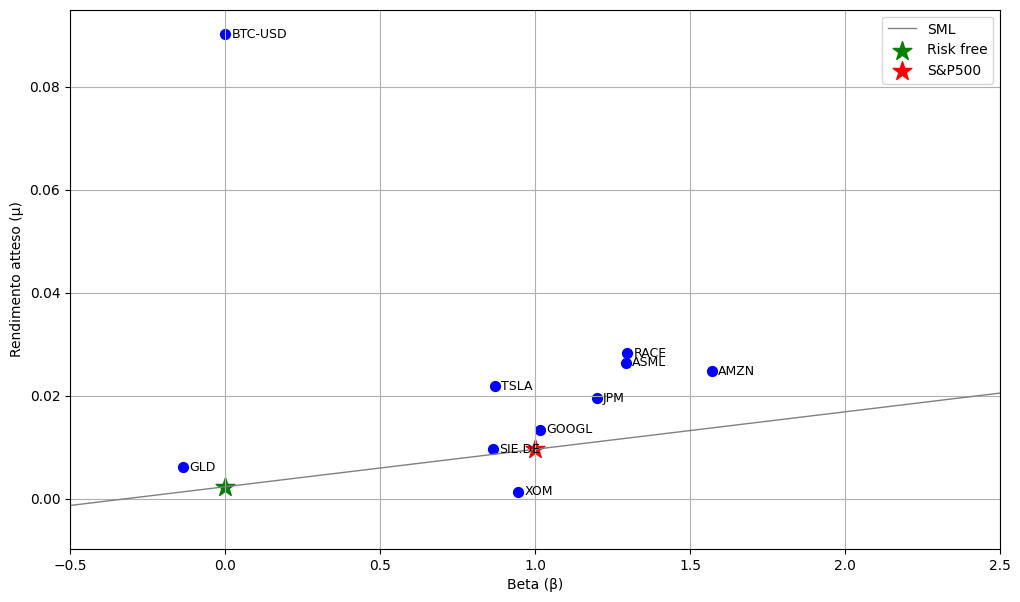

In [39]:
plt.figure(figsize=(12,7))
plt.plot(x, y, label='SML', color='gray',linewidth=1)

plt.scatter(0,rf,
            color='green',
            marker='*',
            s=200,
            label='Risk free')

plt.scatter(1,spy_mean,
            color='red',
            marker='*',
            s=200,
            label='S&P500')

plt.scatter(betas_spy,
            statistics_df_filtered["Expected Return"],
            color='blue',
            s=50)

for i, ticker in enumerate(statistics_df_filtered.index):  
    beta_i = betas_spy[i]
    mu_i = statistics_df_filtered["Expected Return"].iloc[i]
    
    plt.text(beta_i + 0.02,
             mu_i, 
             ticker,
             fontsize=9,
             ha='left',
             va='center')

plt.xlabel("Beta (β)")
plt.ylabel("Rendimento atteso (µ)")
plt.legend()
plt.grid(True)
plt.xlim(-0.5,2.5)
plt.show()

In [40]:
def get_stock_name(ticker_symbol: str):
    ticker = yf.Ticker(ticker_symbol)
    info = ticker.info
    return info.get("longName", "Nome non disponibile")

portfolio = []

for ticker in tickers:
    stock = get_stock_name(ticker)
    portfolio.append(stock)

print(portfolio)

['Alphabet Inc.', 'Tesla, Inc.', 'Amazon.com, Inc.', 'JPMorgan Chase & Co.', 'Exxon Mobil Corporation', 'ASML Holding N.V.', 'Ferrari N.V.', 'Siemens Aktiengesellschaft', 'SPDR Gold Shares', 'Bitcoin USD']


In [41]:
betas = []
mus = []
alpha_jensen = []

for i, ticker in enumerate(statistics_df_filtered.index):  
    beta_i = betas_spy[i]
    betas.append(beta_i)
    mu_i = statistics_df_filtered["Expected Return"].iloc[i]
    mus.append(mu_i)
    sml_beta = beta_i*spy_mean + rf*(1-beta_i)
    aj = (mu_i - sml_beta).round(6)
    alpha_jensen.append(aj)

table_df = pd.DataFrame({
    "Titolo": portfolio,
    "Beta": betas,
    "Rendimento Atteso": mus,
    "Alpha Jensen": alpha_jensen
})

print(table_df)

                       Titolo      Beta  Rendimento Atteso  Alpha Jensen
0               Alphabet Inc.  1.014977           0.013389      0.003709
1                 Tesla, Inc.  0.870049           0.021816      0.013191
2            Amazon.com, Inc.  1.570589           0.024751      0.011030
3        JPMorgan Chase & Co.  1.199395           0.019564      0.008543
4     Exxon Mobil Corporation  0.945744           0.001368     -0.007808
5           ASML Holding N.V.  1.292042           0.026413      0.014718
6                Ferrari N.V.  1.297271           0.028205      0.016472
7  Siemens Aktiengesellschaft  0.865217           0.009658      0.001068
8            SPDR Gold Shares -0.136600           0.006123      0.004821
9                 Bitcoin USD  0.000750           0.090166      0.087865


C:\Users\Riccardo\AppData\Local\Temp\ipykernel_22856\3853252545.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  beta_i = betas_spy[i]


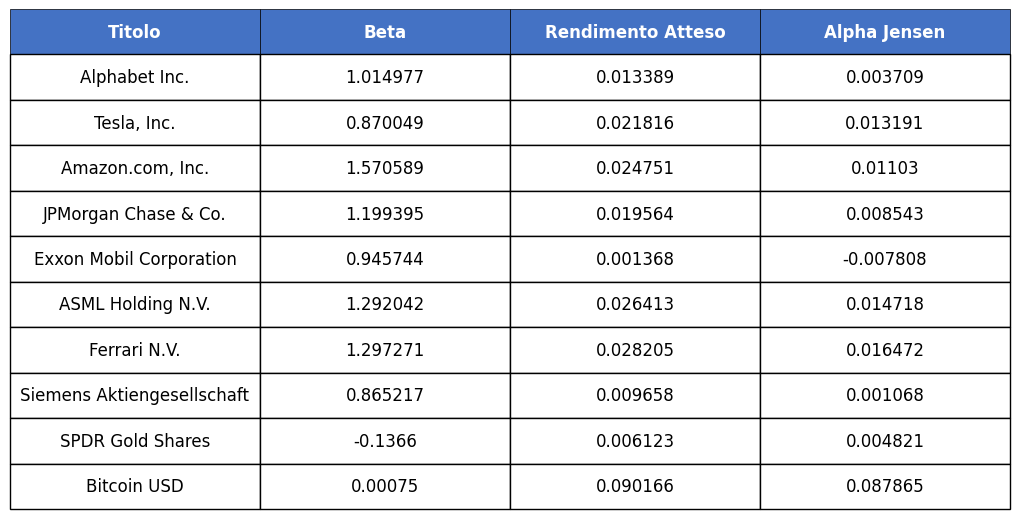

In [42]:
# OUTPUT MIGLIORE
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

# Crea la tabella specificando esattamente dove posizionarla
table = ax.table(cellText=table_df.round(6).values,
                colLabels=table_df.columns,
                cellLoc='center',
                bbox=[0, 0, 1, 1])  

# Stile della tabella
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)  

for j in range(len(table_df.columns)):
    table[(0, j)].set_facecolor('#4472C4')
    table[(0, j)].set_text_props(weight='bold', color='white')
    table[(0, j)].set_edgecolor('black')
    table[(0, j)].set_linewidth(0.5)

# Rimuovi tutti i margini
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

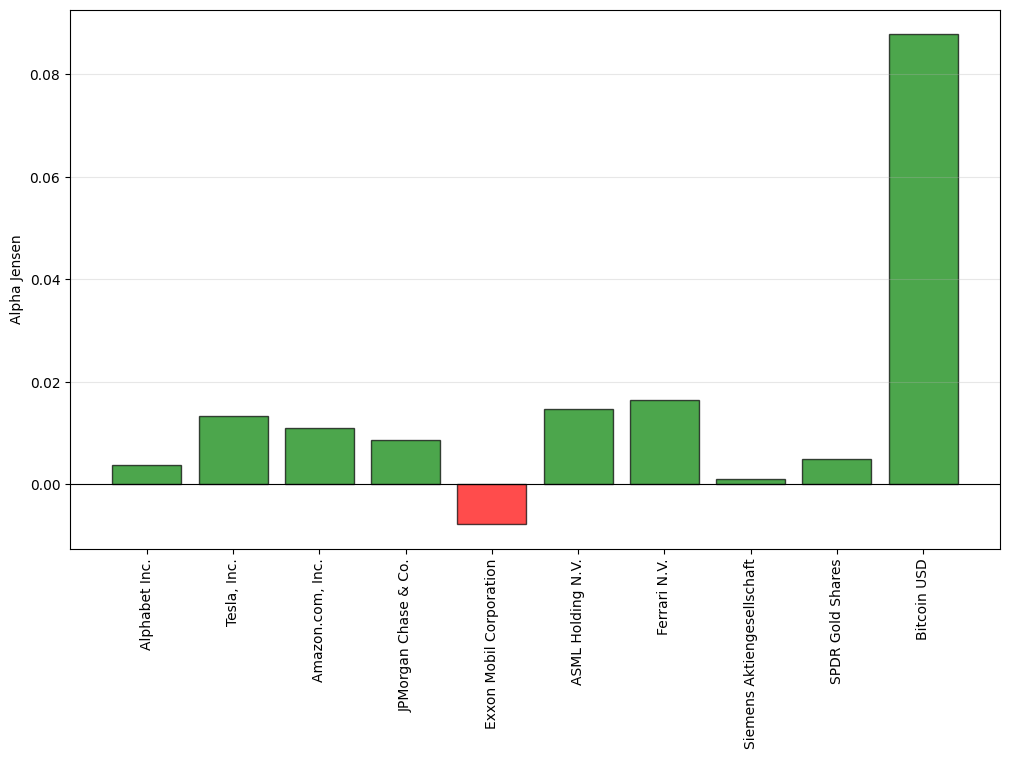

In [43]:
plt.figure(figsize=(12, 7))
colors = ['green' if alpha > 0 else 'red' for alpha in table_df["Alpha Jensen"]]
bars = plt.bar(range(len(table_df)), table_df["Alpha Jensen"], color=colors, alpha=0.7, edgecolor='black')

plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.ylabel('Alpha Jensen')
plt.xticks(range(len(table_df)), table_df['Titolo'], rotation=90)
plt.grid(True, alpha=0.3, axis='y')


plt.show()